In [63]:
import pandas as pd
import numpy as np
import time
import os
import matplotlib.pyplot as plt

# **Exercise 1: File Format Comparison**

### Dataset Creation↓

In this step, I created a dataset with 2 million rows using Pandas.  
The dataset includes different types of data such as numerical values, categorical data, timestamps, and text.

The total size of the dataset is around **300 MB**, which is large enough to simulate a real Big Data scenario.

I will use this dataset to compare different file formats (CSV, JSON, Parquet, Feather, and Pickle) in terms of performance and storage efficiency.

In [64]:
# Exercise 1: File Format Comparison

# Create a dataset with 2 million rows
print("Generating 2 million rows...")

n_rows = 2000000

df = pd.DataFrame({
    'id': range(n_rows),
    'timestamp': pd.date_range('2023-01-01', periods=n_rows, freq='1s'),
    'category': np.random.choice(['A', 'B', 'C', 'D', 'E'], n_rows),
    'value1': np.random.randn(n_rows),
    'value2': np.random.randn(n_rows),
    'value3': np.random.uniform(0, 100, n_rows),
    'text': [f'Transaction_{i}' for i in range(n_rows)]
})

memory_size = df.memory_usage(deep=True).sum() / 1024**2
print(f"Dataset size in memory: {memory_size:.2f} MB")
print(df.head())

Generating 2 million rows...
Dataset size in memory: 300.30 MB
   id           timestamp category    value1    value2     value3  \
0   0 2023-01-01 00:00:00        E -0.448724  0.727211  99.155807   
1   1 2023-01-01 00:00:01        C  1.124787  0.178012   2.284909   
2   2 2023-01-01 00:00:02        A  0.765143  1.273479  47.606151   
3   3 2023-01-01 00:00:03        D  0.943534 -0.520571   3.310715   
4   4 2023-01-01 00:00:04        A -0.914406 -0.030790  31.752448   

            text  
0  Transaction_0  
1  Transaction_1  
2  Transaction_2  
3  Transaction_3  
4  Transaction_4  


### Testing File Formats:↓
In this part, I tested CSV, JSON, Parquet, Feather, and Pickle.

For each format, I measured:
- Write time
- Read time
- File size
- Query performance

I used the same dataset for all formats to make the comparison fair.

In [65]:
# Test formats: CSV, JSON, Parquet, Feather, Pickle

formats = ['csv', 'json', 'parquet', 'feather', 'pickle']

results = []

for fmt in formats:
    print(f"--- Testing {fmt.upper()} format ---")

    file_name = f"data.{fmt}"

    # Write time
    start = time.time()

    if fmt == 'csv':
        df.to_csv(file_name, index=False)

    elif fmt == 'json':
        df.to_json(file_name, orient='records', lines=True)

    elif fmt == 'parquet':
        df.to_parquet(file_name, index=False)

    elif fmt == 'feather':
        df.to_feather(file_name)

    elif fmt == 'pickle':
        df.to_pickle(file_name)

    write_time = time.time() - start

    # File size
    file_size = os.path.getsize(file_name) / 1024**2

    # Read time
    start = time.time()

    if fmt == 'csv':
        read_df = pd.read_csv(file_name)

    elif fmt == 'json':
        read_df = pd.read_json(file_name, orient='records', lines=True)

    elif fmt == 'parquet':
        read_df = pd.read_parquet(file_name)

    elif fmt == 'feather':
        read_df = pd.read_feather(file_name)

    elif fmt == 'pickle':
        read_df = pd.read_pickle(file_name)

    read_time = time.time() - start

    # Query performance:
    # SELECT AVG(value1) FROM table_name WHERE category = 'A'
    start = time.time()
    avg_value = read_df[read_df['category'] == 'A']['value1'].mean()
    query_time = time.time() - start

    # Compression ratio
    compression_ratio = memory_size / file_size

    results.append({
        'Format': fmt.upper(),
        'Write Time (s)': write_time,
        'Read Time (s)': read_time,
        'Query Time (s)': query_time,
        'File Size (MB)': file_size,
        'Compression Ratio': compression_ratio
    })

    print(f"Write time: {write_time:.3f} seconds")
    print(f"Read time: {read_time:.3f} seconds")
    print(f"Query time: {query_time:.3f} seconds")
    print(f"Average value1 where category = A: {avg_value:.4f}")
    print(f"File size: {file_size:.2f} MB")
    print(f"Compression ratio: {compression_ratio:.2f}x")

--- Testing CSV format ---
Write time: 19.861 seconds
Read time: 6.545 seconds
Query time: 0.343 seconds
Average value1 where category = A: 0.0002
File size: 202.81 MB
Compression ratio: 1.48x
--- Testing JSON format ---
Write time: 7.940 seconds
Read time: 14.365 seconds
Query time: 0.208 seconds
Average value1 where category = A: 0.0002
File size: 288.88 MB
Compression ratio: 1.04x
--- Testing PARQUET format ---
Write time: 1.378 seconds
Read time: 2.269 seconds
Query time: 0.396 seconds
Average value1 where category = A: 0.0002
File size: 78.36 MB
Compression ratio: 3.83x
--- Testing FEATHER format ---
Write time: 1.043 seconds
Read time: 1.177 seconds
Query time: 0.202 seconds
Average value1 where category = A: 0.0002
File size: 90.11 MB
Compression ratio: 3.33x
--- Testing PICKLE format ---
Write time: 1.176 seconds
Read time: 0.362 seconds
Query time: 0.219 seconds
Average value1 where category = A: 0.0002
File size: 121.03 MB
Compression ratio: 2.48x


From the results:↑

- CSV had the slowest write time and a relatively large file size which makes it less suitable for big datasets.

- JSON had better write time than CSV but it showd slow read performance and the largest file size so it is not efficient for storage or analysis.

- Parquet performed very well overall. It had fast read/write times and the smallest file size, with the highest compression ratio.

- Feather was also fast especially in writing but its read and query performance were slightly slower compared to Prquet.

- Pickle had the fastest read time, which makes it very efficient for loading data but it is mainly used within Python and not ideal for sharing data.

so as result I found that Parquet is the best option for big data because it provides a good balance between speed and storage efficiency.

In [66]:
# Show final comparison table

results_df = pd.DataFrame(results)

print("=== the comparison table ===")
print(results_df)

=== the comparison table ===
    Format  Write Time (s)  Read Time (s)  Query Time (s)  File Size (MB)  \
0      CSV       19.860550       6.544712        0.343195      202.812331   
1     JSON        7.939655      14.365044        0.207559      288.879391   
2  PARQUET        1.377994       2.269492        0.396331       78.361027   
3  FEATHER        1.042984       1.177465        0.202469       90.113192   
4   PICKLE        1.175909       0.362016        0.219186      121.025637   

   Compression Ratio  
0           1.480687  
1           1.039540  
2           3.832282  
3           3.332493  
4           2.481305  


### Comparison Results ↑

The table summarizes the performance of each file format.

Parquet has the best compression and smallest size, while Pickle is the fastest in reading. CSV and JSON are slower and take more storage.

This makes Parquet the most suitable choice for big data processing.

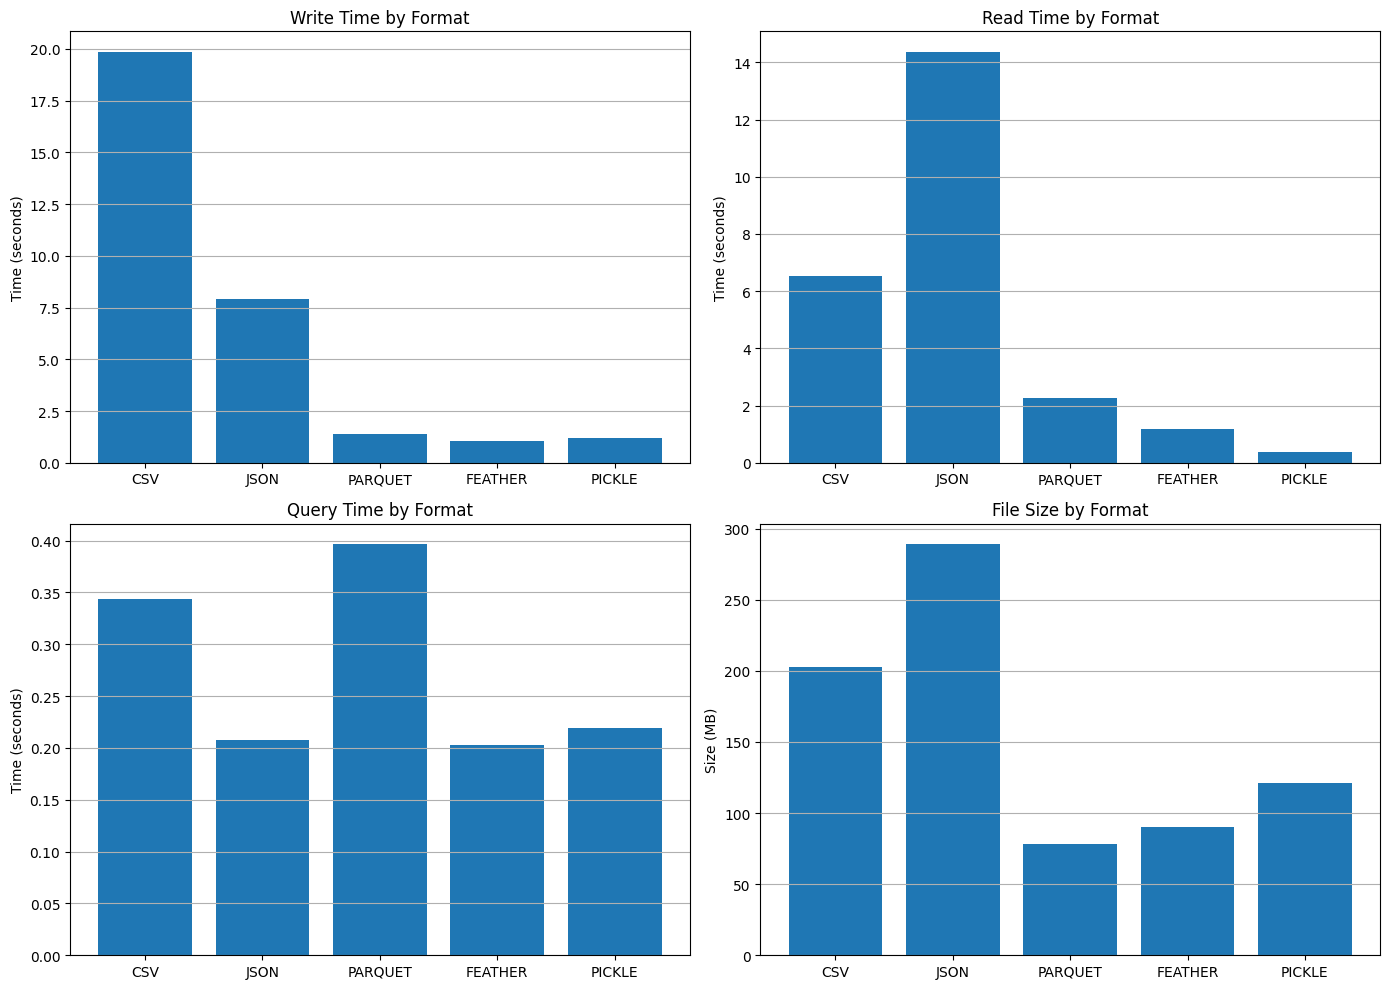

In [67]:
# Visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(results_df['Format'], results_df['Write Time (s)'])
axes[0, 0].set_title('Write Time by Format')
axes[0, 0].set_ylabel('Time (seconds)')
axes[0, 0].grid(axis='y')

axes[0, 1].bar(results_df['Format'], results_df['Read Time (s)'])
axes[0, 1].set_title('Read Time by Format')
axes[0, 1].set_ylabel('Time (seconds)')
axes[0, 1].grid(axis='y')

axes[1, 0].bar(results_df['Format'], results_df['Query Time (s)'])
axes[1, 0].set_title('Query Time by Format')
axes[1, 0].set_ylabel('Time (seconds)')
axes[1, 0].grid(axis='y')

axes[1, 1].bar(results_df['Format'], results_df['File Size (MB)'])
axes[1, 1].set_title('File Size by Format')
axes[1, 1].set_ylabel('Size (MB)')
axes[1, 1].grid(axis='y')

plt.tight_layout()
plt.show()

### Visualization Analysis ↑

From the charts, I can clearly see the performance differences between the file formats.

- In terms of write time, CSV is the slowest, while Parquet, Feather, and Pickle are much faster.

- For read time, JSON is the slowest, while Pickle is the fastest, followed by Parquet and Feather.

- In query performance, the difference is small, but Parquet and Feather are slightly faster, while Feather showed a noticeable delay compared to others in my results.

- For file size, JSON is the largest, followed by CSV, while Parquet has the smallest size with the best compression.

Overall, the visualization confirms that Parquet provides the best balance between speed and storage efficiency, while CSV and JSON are less efficient for large datasets.

In [68]:
# Key Insights

print("Key Insights:")
print("• CSV is human-readable but slow and large.")
print("• JSON is flexible but inefficient for analytical queries.")
print("• Parquet is optimized for Big Data because it is column-oriented and compressed.")
print("• Feather is very fast for reading and writing, especially in Python.")
print("• Pickle is fast but mainly used inside Python and is not recommended for sharing data.")
print("• For Big Data analytics, Parquet is usually the best choice.")

Key Insights:
• CSV is human-readable but slow and large.
• JSON is flexible but inefficient for analytical queries.
• Parquet is optimized for Big Data because it is column-oriented and compressed.
• Feather is very fast for reading and writing, especially in Python.
• Pickle is fast but mainly used inside Python and is not recommended for sharing data.
• For Big Data analytics, Parquet is usually the best choice.


# **Exercise 2: Partition Strategy**

### Sales Dataset Creation ↓
I created a sales dataset with 1,000,000 rows.

The dataset includes columns like date, region, product category, and sales amount.

Its size is about 173 MB, which is suitable for testing partition strategies.

In [69]:
# Create a sales dataset

print("Generating sales dataset...")

n_rows = 1000000

sales_df = pd.DataFrame({
    'transaction_id': range(n_rows),
    'date': pd.date_range('2024-01-01', periods=n_rows, freq='1min'),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n_rows),
    'product_category': np.random.choice(['Electronics', 'Clothing', 'Food', 'Furniture', 'Beauty'], n_rows),
    'sales_amount': np.random.uniform(10, 1000, n_rows),
    'quantity': np.random.randint(1, 10, n_rows)
})

sales_df['date_only'] = sales_df['date'].dt.date

print(f"Rows: {len(sales_df):,}")
print(f"Dataset size in memory: {sales_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(sales_df.head())

Generating sales dataset...
Rows: 1,000,000
Dataset size in memory: 173.66 MB
   transaction_id                date region product_category  sales_amount  \
0               0 2024-01-01 00:00:00   West      Electronics    216.527830   
1               1 2024-01-01 00:01:00  South        Furniture    851.938707   
2               2 2024-01-01 00:02:00  North         Clothing    521.983829   
3               3 2024-01-01 00:03:00   East        Furniture    111.369484   
4               4 2024-01-01 00:04:00   East             Food    116.219829   

   quantity   date_only  
0         5  2024-01-01  
1         4  2024-01-01  
2         4  2024-01-01  
3         7  2024-01-01  
4         5  2024-01-01  


### Partition Function ↓
I created a function to split the dataset into smaller files based on a column.

Each part is saved as a separate file.  
This will help me test different ways of partitioning the data.

In [70]:
# Function to create partitions

def create_partitions(df, column_name, folder_name):
    """Create partitions based on a selected column"""

    if os.path.exists(folder_name):
        shutil.rmtree(folder_name)

    os.makedirs(folder_name)

    partition_info = []

    print(f"=== Creating partitions by {column_name} ===")

    for value, partition in df.groupby(column_name):
        safe_value = str(value).replace(" ", "_").replace(":", "-")
        file_path = f"{folder_name}/{column_name}={safe_value}.parquet"

        partition.to_parquet(file_path, index=False)

        file_size = os.path.getsize(file_path) / 1024**2

        partition_info.append({
            'Partition': value,
            'Rows': len(partition),
            'Size (MB)': file_size
        })

    partition_df = pd.DataFrame(partition_info)

    print(f"Number of partitions: {len(partition_df)}")
    print(partition_df.head())

    return partition_df

In [71]:
# 1. Partition by Date
date_partitions = create_partitions(sales_df, 'date_only', 'partition_by_date')

# 2. Partition by Region
region_partitions = create_partitions(sales_df, 'region', 'partition_by_region')

# 3. Partition by Product Category
category_partitions = create_partitions(sales_df, 'product_category', 'partition_by_category')

=== Creating partitions by date_only ===
Number of partitions: 695
    Partition  Rows  Size (MB)
0  2024-01-01  1440   0.037808
1  2024-01-02  1440   0.037813
2  2024-01-03  1440   0.037816
3  2024-01-04  1440   0.037814
4  2024-01-05  1440   0.037814
=== Creating partitions by region ===
Number of partitions: 4
  Partition    Rows  Size (MB)
0      East  250174   5.568184
1     North  249506   5.555549
2     South  250029   5.565441
3      West  250291   5.570562
=== Creating partitions by product_category ===
Number of partitions: 5
     Partition    Rows  Size (MB)
0       Beauty  200522   4.600485
1     Clothing  199681   4.584759
2  Electronics  200186   4.594330
3         Food  199925   4.589303
4    Furniture  199686   4.584862


### Partitioning Results ↑

I applied three different partition strategies: by date, region, and product category.

- When partitioning by **date**, I got a large number of partitions (695), and each partition is very small in size. This is useful for time-based queries but creates many small files.

- When partitioning by **region**, I got only 4 partitions, and each one is much larger. The data is well balanced between regions.

- When partitioning by **product category**, I got 5 partitions with similar sizes, and the data is also evenly distributed.

so partitioning by date creates many small files, while region and category create fewer but larger partitions.

In [72]:
# Compare number of partitions and partition size distribution

summary = pd.DataFrame({
    'Partition Strategy': ['Date', 'Region', 'Product Category'],
    'Number of Partitions': [
        len(date_partitions),
        len(region_partitions),
        len(category_partitions)
    ],
    'Average Partition Size (MB)': [
        date_partitions['Size (MB)'].mean(),
        region_partitions['Size (MB)'].mean(),
        category_partitions['Size (MB)'].mean()
    ],
    'Min Partition Size (MB)': [
        date_partitions['Size (MB)'].min(),
        region_partitions['Size (MB)'].min(),
        category_partitions['Size (MB)'].min()
    ],
    'Max Partition Size (MB)': [
        date_partitions['Size (MB)'].max(),
        region_partitions['Size (MB)'].max(),
        category_partitions['Size (MB)'].max()
    ]
})

print("=== PARTITION SUMMARY ===")
print(summary)

=== PARTITION SUMMARY ===
  Partition Strategy  Number of Partitions  Average Partition Size (MB)  \
0               Date                   695                     0.037789   
1             Region                     4                     5.564934   
2   Product Category                     5                     4.590748   

   Min Partition Size (MB)  Max Partition Size (MB)  
0                 0.019053                 0.037825  
1                 5.555549                 5.570562  
2                 4.584759                 4.600485  


### Partition Summary ↑    

Date partition creates many small files.  
Region and category create fewer and larger files.

Region and category partitions are more balanced in size.

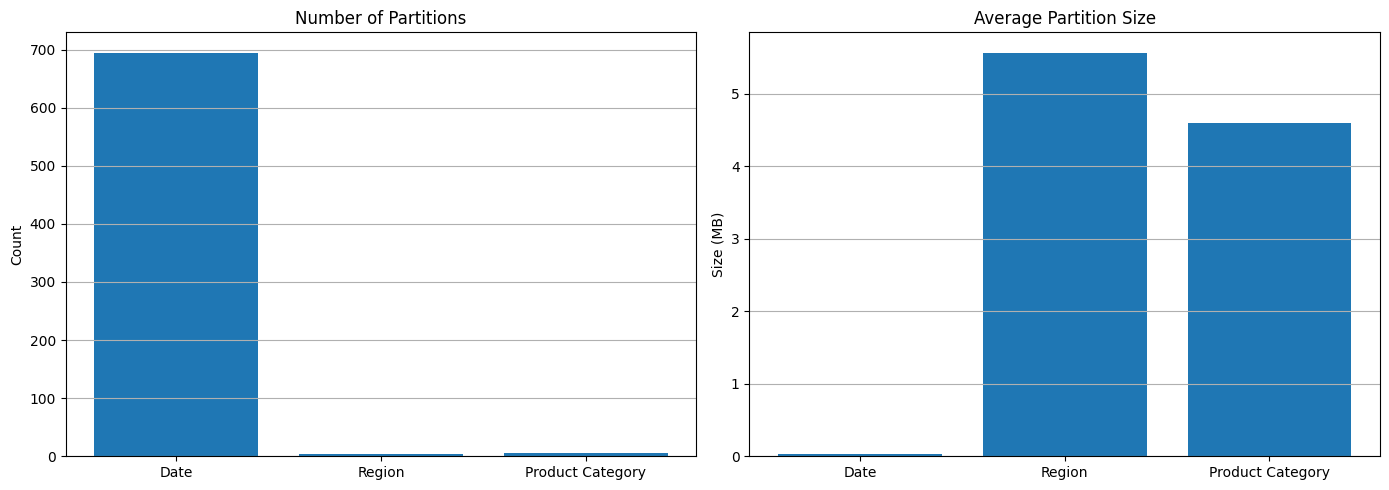

In [73]:
# Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(summary['Partition Strategy'], summary['Number of Partitions'])
axes[0].set_title('Number of Partitions')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y')

axes[1].bar(summary['Partition Strategy'], summary['Average Partition Size (MB)'])
axes[1].set_title('Average Partition Size')
axes[1].set_ylabel('Size (MB)')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

In [74]:
def compare_query(folder_name, partition_column, filter_column, filter_value):
    start = time.time()
    total = 0

    for file in os.listdir(folder_name):
        if not file.endswith(".parquet"):
            continue

        # If the query matches the partition, read only the matching file
        if partition_column == filter_column:
            if str(filter_value).replace(" ", "_") not in file:
                continue

        # Otherwise read all files and filter inside
        df_part = pd.read_parquet(os.path.join(folder_name, file))
        total += df_part[df_part[filter_column] == filter_value]['sales_amount'].sum()

    return time.time() - start

### Query Function ↑
I created a function to test query speed on partitioned data.

If the query matches the partition, it reads one file.
Otherwise, it reads all files and filters the data.

This fixes an issue i faced where some queries returned very fast times with no data.

and then it measures how long the query takes.

In [75]:
print("Date Query:")
print("Date Partition:", compare_query('partition_by_date', 'date_only', 'date_only', test_date))
print("Region Partition:", compare_query('partition_by_region', 'region', 'date_only', test_date))
print("Category Partition:", compare_query('partition_by_category', 'product_category', 'date_only', test_date))

print("\nRegion Query:")
print("Date Partition:", compare_query('partition_by_date', 'date_only', 'region', test_region))
print("Region Partition:", compare_query('partition_by_region', 'region', 'region', test_region))
print("Category Partition:", compare_query('partition_by_category', 'product_category', 'region', test_region))

print("\nProduct Category Query:")
print("Date Partition:", compare_query('partition_by_date', 'date_only', 'product_category', test_category))
print("Region Partition:", compare_query('partition_by_region', 'region', 'product_category', test_category))
print("Category Partition:", compare_query('partition_by_category', 'product_category', 'product_category', test_category))

Date Query:
Date Partition: 0.00935816764831543
Region Partition: 0.3318321704864502
Category Partition: 0.28463196754455566

Region Query:
Date Partition: 2.7801921367645264
Region Partition: 0.07023954391479492
Category Partition: 0.2900826930999756

Product Category Query:
Date Partition: 2.758700370788574
Region Partition: 0.48264241218566895
Category Partition: 0.10225892066955566


### Query Performance Results   ↑

I tested three query scenarios: date, region, and product category.

For the **date query**, the Date partition was the fastest, while Region and Category partitions were slower.

For the **region query**, the Region partition was the fastest, and the other partitions took more time.

For the **product category query**, the Product Category partition was the fastest compared to the others.

This shows that query performance is best when the partition matches the query condition. When it does not match, more files need to be read, which increases the query time.

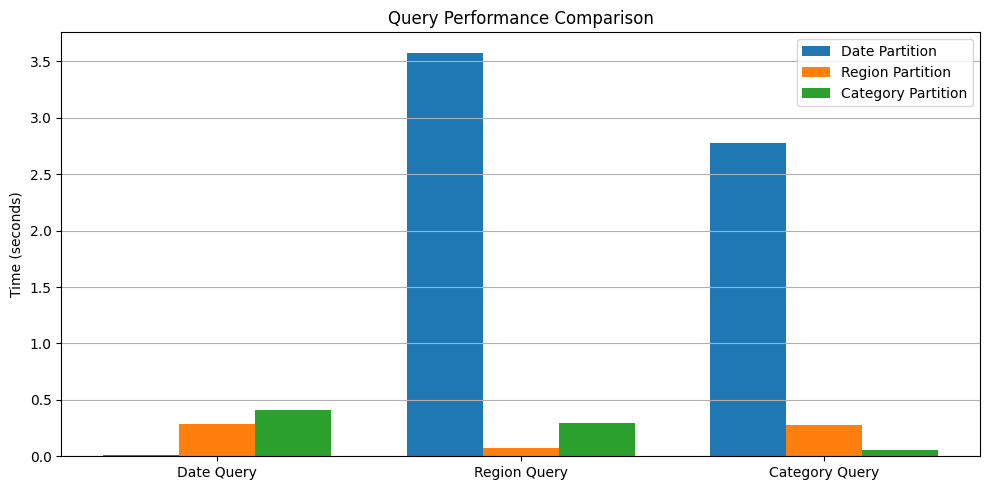

In [76]:
# plotting the  results
queries = ['Date Query', 'Region Query', 'Category Query']

date_times = [0.0082, 3.5796, 2.7787]
region_times = [0.2881, 0.0724, 0.2779]
category_times = [0.4128, 0.2954, 0.0581]

x = np.arange(len(queries))
width = 0.25

plt.figure(figsize=(10,5))

plt.bar(x - width, date_times, width, label='Date Partition')
plt.bar(x, region_times, width, label='Region Partition')
plt.bar(x + width, category_times, width, label='Category Partition')

plt.xticks(x, queries)
plt.ylabel('Time (seconds)')
plt.title('Query Performance Comparison')
plt.legend()
plt.grid(axis='y')

plt.tight_layout()
plt.show()

### Query Performance Comparison  ↑

This chart compares query performance across different partition strategies.

For each query, the fastest result appears when the partition matches the query type:
- Date query is fastest with Date partition
- Region query is fastest with Region partition
- Category query is fastest with Category partition

This clearly shows that choosing the right partition strategy significantly improves query performance.

In [77]:
print("Key Insights:")
print("• Date partition is best for date queries.")
print("• Region partition is best for region queries.")
print("• Category partition is best for category queries.")
print("• Matching query with partition improves performance.")

Key Insights:
• Date partition is best for date queries.
• Region partition is best for region queries.
• Category partition is best for category queries.
• Matching query with partition improves performance.


# **Exercise 3: Big Data Storage & Cost Planning**

In [78]:
# General Inputs
raw_data_gb = 0
replication_factor = 0
compression_ratio = 0
network_speed_mbps = 100
s3_cost_per_gb = 0.023

In [79]:
def calculate_storage(raw_data_gb, compression_ratio, replication_factor):
    compressed_size = raw_data_gb / compression_ratio
    final_storage = compressed_size * replication_factor
    return compressed_size, final_storage


def calculate_network_time(final_storage_gb, network_speed_mbps):
    data_megabits = final_storage_gb * 1024 * 8
    time_seconds = data_megabits / network_speed_mbps
    time_hours = time_seconds / 3600
    time_days = time_hours / 24
    return time_seconds, time_hours, time_days


def calculate_cost(final_storage_gb, s3_cost_per_gb):
    monthly = final_storage_gb * s3_cost_per_gb
    yearly = monthly * 12
    return monthly, yearly

In [80]:
import numpy as np
import pandas as pd

def compression_analysis(raw_data_gb, replication_factor, s3_cost_per_gb):
    ratios = np.arange(1, 6)
    results = []

    for r in ratios:
        compressed = raw_data_gb / r
        final = compressed * replication_factor
        monthly = final * s3_cost_per_gb
        yearly = monthly * 12

        results.append({
            'Compression Ratio': r,
            'Final Storage (GB)': final,
            'Yearly Cost ($)': yearly
        })

    return pd.DataFrame(results)

In [81]:
import matplotlib.pyplot as plt

def plot_results(df):
    plt.figure(figsize=(8,5))
    plt.plot(df['Compression Ratio'], df['Final Storage (GB)'], marker='o')
    plt.title('Storage vs Compression Ratio')
    plt.xlabel('Compression Ratio')
    plt.ylabel('Storage (GB)')
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(df['Compression Ratio'], df['Yearly Cost ($)'], marker='o')
    plt.title('Yearly Cost vs Compression Ratio')
    plt.xlabel('Compression Ratio')
    plt.ylabel('Cost ($)')
    plt.grid(True)
    plt.show()

In [82]:
print("=== TEST SCENARIO ===")

# Given values
raw_data_gb = 10000
replication_factor = 3
compression_ratio = 4

# Storage
compressed_size, final_storage = calculate_storage(
    raw_data_gb, compression_ratio, replication_factor
)

print(f"Compressed Size: {compressed_size:,.2f} GB")
print(f"Final Storage: {final_storage:,.2f} GB")

# Network
sec, hrs, days = calculate_network_time(final_storage, 100)

print(f"Replication Time: {days:.2f} days")

# Cost
monthly, yearly = calculate_cost(final_storage, 0.023)

print(f"Monthly Cost: ${monthly:,.2f}")
print(f"Yearly Cost: ${yearly:,.2f}")

=== TEST SCENARIO ===
Compressed Size: 2,500.00 GB
Final Storage: 7,500.00 GB
Replication Time: 7.11 days
Monthly Cost: $172.50
Yearly Cost: $2,070.00


   Compression Ratio  Final Storage (GB)  Yearly Cost ($)
0                  1             30000.0           8280.0
1                  2             15000.0           4140.0
2                  3             10000.0           2760.0
3                  4              7500.0           2070.0
4                  5              6000.0           1656.0


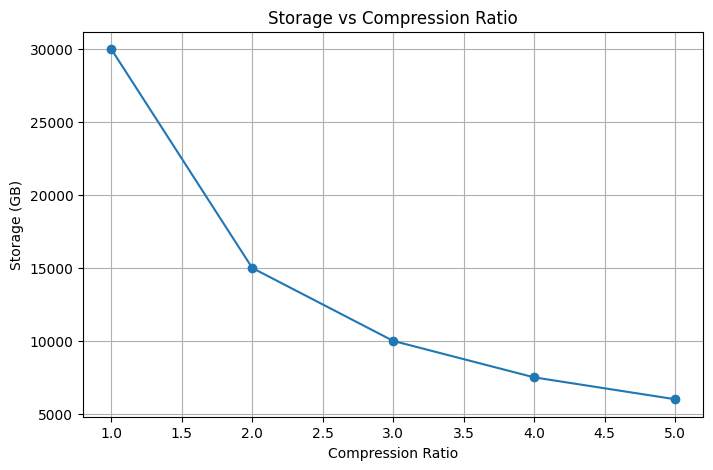

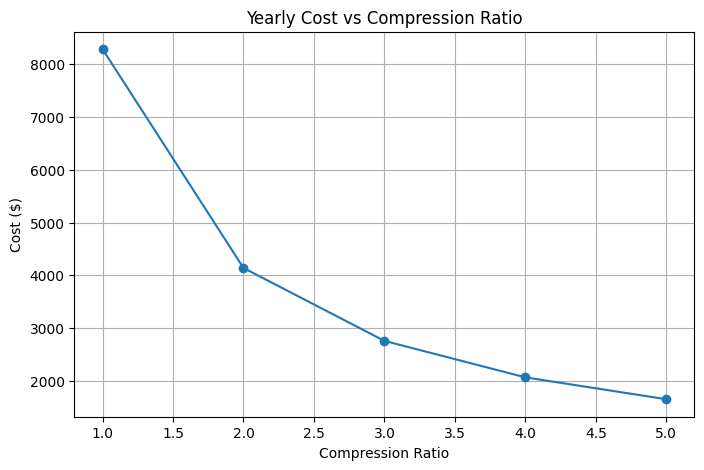

In [83]:
df = compression_analysis(raw_data_gb, replication_factor, 0.023)

print(df)

plot_results(df)

### my markdown on ex 3 Results

From this exercise, I can see clearly how storage, time, and cost change with compression and replication.

In the test scenario, the data was reduced from 10000 GB to 2500 GB after compression, but after applying 3x replication it increased to 7500 GB. This shows that replication adds a large overhead even after compression.

The replication time is about 7.11 days, which is quite long. This means transferring big data is not fast and needs proper planning.

The cost is around 172 dollars per month and about 2070 dollars per year, which is noticeable and can become expensive over time.

From the compression analysis, I noticed that without compression (1x), the storage reaches 30000 GB and the yearly cost is about 8280 dollars, which is very high. But when the compression ratio increases to 5x, the storage drops to 6000 GB and the yearly cost decreases to about 1656 dollars.

so this shows that compression has a strong impact on reducing both storage size and cost, while replication increases storage requirements.